## PyCaret para Classificação

## Meu ambiente de trabalho

In [1]:
import sys
print(sys.executable)

/home/fabiene/anaconda3/envs/pycaret-env/bin/python


### Para usar o PyCaret com estabilidade, crie um ambiente com Python 3.10 ou 3.11. Eles são as versões "porto seguro" para Machine Learning hoje.

No linux, sugestão

#### 1. Cria o ambiente com uma versão estável do Python

conda create -n projeto_automl_pycaret python=3.11 -y

#### 2. Ativa o ambiente
conda activate projeto_automl_pycaret

#### 3. Instala o PyCaret pelo conda (muito mais seguro que pip neste caso)
conda install -c conda-forge pycaret -y

In [2]:
import sys
print(sys.version)

3.11.11 (main, Dec 11 2024, 16:28:39) [GCC 11.2.0]


### Instalação e configuração da biblioteca


In [3]:
#!pip install pycaret # já foi instalado



In [4]:
import pycaret
print(pycaret.__version__)

3.3.2


In [5]:
import numpy as np
# from pycaret.utils import enable_colab
# enable_colab() # só no jupyter colab

# Base de dados e seu carregamento

#### Coletar a base de dados com o tipo de dados "Data Types" e como utilizar "Default Task"	

Target Variable 1=> variável para a previsão 

In [6]:
from pycaret.datasets import get_data

todas_bases = get_data('index')
todas_bases.tail()


,Dataset,Data Types,Default Task,Target Variable 1,Target Variable 2,# Instances,# Attributes,Missing Values
0,anomaly,Multivariate,Anomaly Detection,NaN,NaN,1000,10,N
1,france,Multivariate,Association Rule Mining,InvoiceNo,Description,8557,8,N
2,germany,Multivariate,Association Rule Mining,InvoiceNo,Description,9495,8,N
3,bank,Multivariate,Classification (Binary),deposit,NaN,45211,17,N
4,blood,Multivariate,Classification (Binary),Class,NaN,748,5,N
5,cancer,Multivariate,Classification (Binary),Class,NaN,683,10,N
6,credit,Multivariate,Classification (Binary),default,NaN,24000,24,N
7,diabetes,Multivariate,Classification (Binary),Class variable,NaN,768,9,N
8,electrical_grid,Multivariate,Classification (Binary),stabf,NaN,10000,14,N
9,employee,Multivariate,Classification (Binary),left,NaN,14999,10,N


,Dataset,Data Types,Default Task,Target Variable 1,Target Variable 2,# Instances,# Attributes,Missing Values
51,gold,Multivariate,Regression,Gold_T+22,NaN,2558,121,N
52,house,Multivariate,Regression,SalePrice,NaN,1461,81,Y
53,insurance,Multivariate,Regression,charges,NaN,1338,7,N
54,parkinsons,Multivariate,Regression,PPE,NaN,5875,22,N
55,traffic,Multivariate,Regression,traffic_volume,NaN,48204,8,N


iris	

Data Types: Multivariate

Default Task: Classification (Multiclass)

Target Variable 1: species

In [7]:
dataset = get_data('iris') # iris é o nome da base

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [8]:
dataset.tail() # colunas com a informação das plantas

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [9]:
type(dataset)

pandas.core.frame.DataFrame

In [10]:
dataset.shape

(150, 5)

- Atributos (ou features) são as propriedades ou características individuais de um objeto ou entidade que servem como dados de entrada para um modelo.

Numéricos: Valores quantitativos, como idade, temperatura ou preço.

Categóricos: Valores qualitativos que representam categorias, como cor, gênero ou estado civil. Estes frequentemente precisam de transformações como one-hot encoding para serem processados por algoritmos. 


In [11]:
print(f'quantidade de dados {dataset.shape[0]} e quantidade de colunas (atributos e alvos) {dataset.shape[1]}.')

quantidade de dados 150 e quantidade de colunas (atributos e alvos) 5.


pesquisar a planta iris setosa virginica versicolor

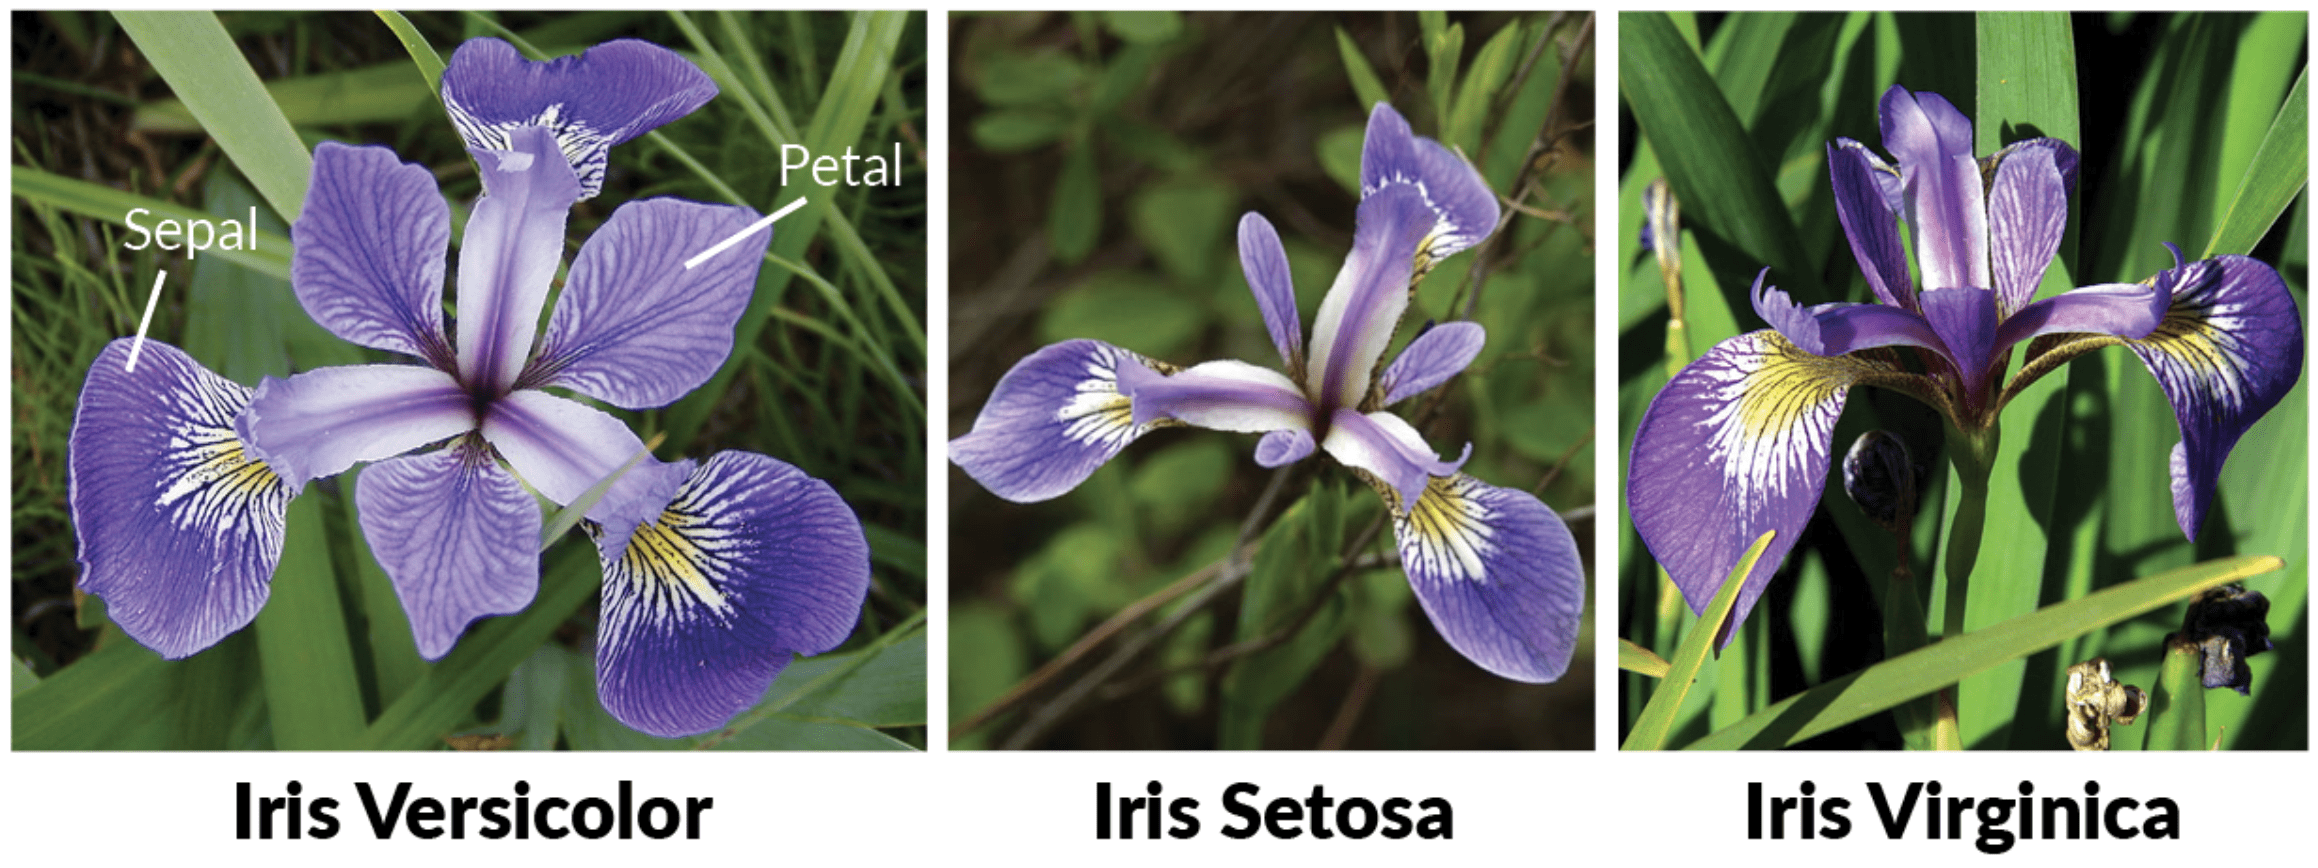


In [12]:
list(dataset['species'].unique())

['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

## contagem de cada tipo de planta iris

In [13]:
np.unique(dataset['species'], return_counts = True)

(array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object),
 array([50, 50, 50]))

In [14]:
# criando a variável de treinamento, amostra, com fração de 90% dos dados
# o random_state sempre manterá os mesmos registros, como a mesma semente, que quando rodarmos sempre mostrar o mesmo valor
# se for random_state o sorteio dos dados serão diferentes
base_treinamento = dataset.sample(frac=0.9, random_state=1)
base_treinamento.shape

(135, 5)

In [15]:
base_treinamento.head() # sorteio aleatório de treinamento

,sepal_length,sepal_width,petal_length,petal_width,species
14,5.8,4.0,1.2,0.2,Iris-setosa
98,5.1,2.5,3.0,1.1,Iris-versicolor
75,6.6,3.0,4.4,1.4,Iris-versicolor
16,5.4,3.9,1.3,0.4,Iris-setosa
131,7.9,3.8,6.4,2.0,Iris-virginica


In [16]:
# para o teste, pegar o index que não foi sorteado no treinamento
base_teste = dataset.drop(base_treinamento.index)
base_teste.shape


(15, 5)

In [17]:
# base de dados do teste

In [18]:
base_teste

,sepal_length,sepal_width,petal_length,petal_width,species
20,5.4,3.4,1.7,0.2,Iris-setosa
25,5.0,3.0,1.6,0.2,Iris-setosa
37,4.9,3.1,1.5,0.1,Iris-setosa
50,7.0,3.2,4.7,1.4,Iris-versicolor
68,6.2,2.2,4.5,1.5,Iris-versicolor
71,6.1,2.8,4.0,1.3,Iris-versicolor
72,6.3,2.5,4.9,1.5,Iris-versicolor
79,5.7,2.6,3.5,1.0,Iris-versicolor
96,5.7,2.9,4.2,1.3,Iris-versicolor
101,5.8,2.7,5.1,1.9,Iris-virginica


In [19]:
base_treinamento.index # index sorteados no treinamento

Index([ 14,  98,  75,  16, 131,  56, 141,  44,  29, 120,
       ...
        81,  60,   0,   1,  57,  22,  61,  63,   7,  86],
      dtype='int64', length=135)

In [20]:
base_teste.index # o que sobrou para ser teste

Index([20, 25, 37, 50, 68, 71, 72, 79, 96, 101, 129, 133, 134, 137, 140], dtype='int64')

## Configuração do ambiente PyCaret



importação do setup



inicialização do ambiente (setup)

parâmetro data de treinamento, target objetivo a previsão da species, com session_id =1 (reproduzir o experimento, como o seed, toda a vez executado terá o mesmo valor (parecido com o random_state)

In [21]:

from pycaret.classification import setup
experimento = setup(data = base_treinamento, target = 'species', session_id=1)


,Description,Value
0,Session id,1
1,Target,species
2,Target type,Multiclass
3,Target mapping,"Iris-setosa: 0, Iris-versicolor: 1, Iris-virginica: 2"
4,Original data shape,"(135, 5)"
5,Transformed data shape,"(135, 5)"
6,Transformed train set shape,"(94, 5)"
7,Transformed test set shape,"(41, 5)"
8,Numeric features,4
9,Preprocess,True


criar o ambiente do pycaret, processamento, com o tipo de dados. 


id da sessão 1

target species

target type, há 3 tipos de plantas iris (unique)

automáticamente faz o label encoded =>
Target mapping	Iris-setosa: 0, Iris-versicolor: 1, Iris-virginica: 2

original data, data original 


In [22]:
experimento


## Treinamento de vários modelos com validação cruzada

Parte mais importantes, treinamento com vários modelos de machine learning para identificar o algoritmo que terá o melhor desempenho na base de dados.

Usa o sklearning,


3 ou 4 linhas de teste por algoritmo


compare_models que estão pré-definidos, sort accuracy, validação cruzada usamos o fold 10


teoria da validação: https://www.youtube.com/watch?reload=9&v=RczbeFs_WbQ

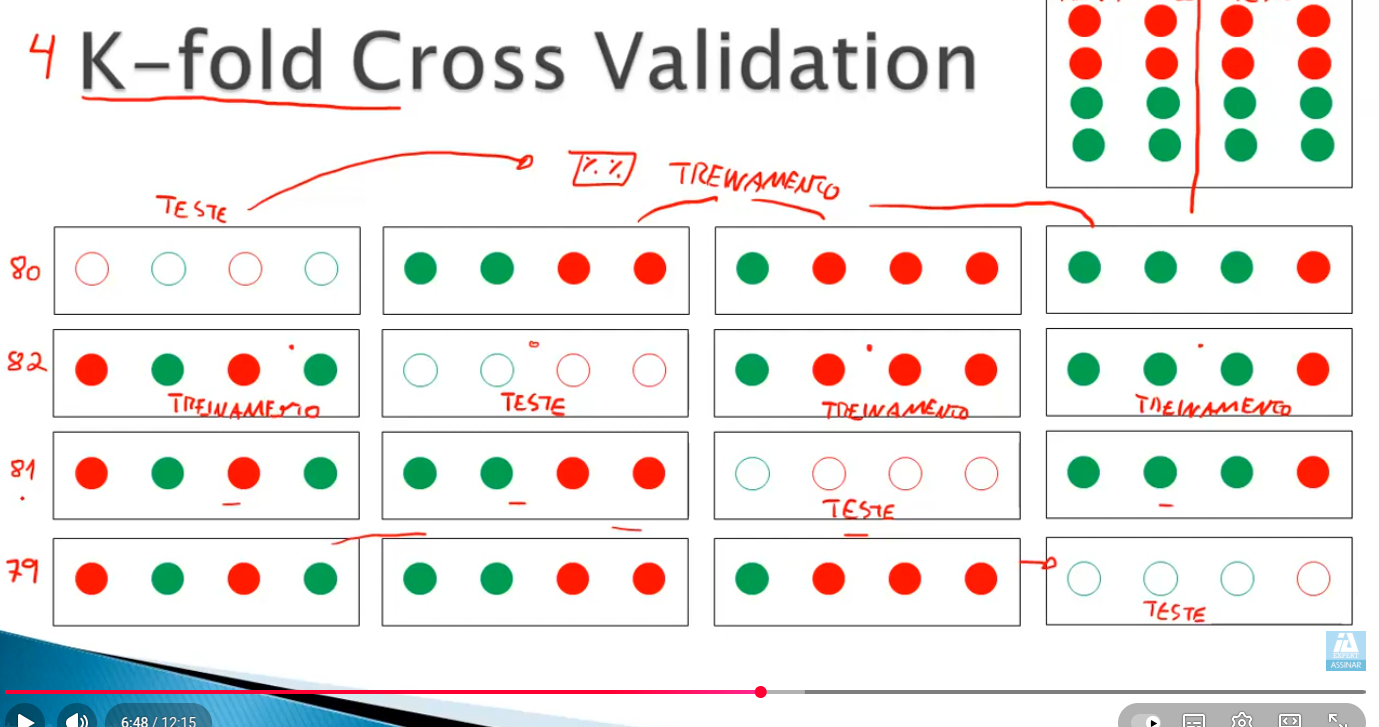

In [23]:
# validação cruzada
from pycaret.classification import compare_models

modelos = compare_models(sort = 'Accuracy', fold = 10)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
qda,Quadratic Discriminant Analysis,0.9778,0.0000,0.9778,0.9833,0.9771,0.9667,0.9698,0.0050
lda,Linear Discriminant Analysis,0.9778,0.0000,0.9778,0.9833,0.9771,0.9667,0.9698,0.0050
nb,Naive Bayes,0.9689,0.9938,0.9689,0.9762,0.9678,0.9528,0.9571,0.0040
dt,Decision Tree Classifier,0.9689,0.9762,0.9689,0.9762,0.9678,0.9528,0.9571,0.0040
et,Extra Trees Classifier,0.9689,0.9981,0.9689,0.9762,0.9678,0.9528,0.9571,0.0180
rf,Random Forest Classifier,0.9578,0.9934,0.9578,0.9678,0.9564,0.9361,0.9420,0.0230
gbc,Gradient Boosting Classifier,0.9578,0.0000,0.9578,0.9678,0.9564,0.9361,0.9420,0.0310
knn,K Neighbors Classifier,0.9567,0.9917,0.9567,0.9670,0.9553,0.9346,0.9407,0.0820
lr,Logistic Regression,0.9467,0.0000,0.9467,0.9595,0.9450,0.9195,0.9269,0.2070
lightgbm,Light Gradient Boosting Machine,0.9456,0.9877,0.9456,0.9536,0.9446,0.9182,0.9227,28.4050


In [24]:
modelos # ordenação com base na acurácia, que é o percentual de acerto. 

QuadraticDiscriminantAnalysis(priors=None, reg_param=0.0,
                              store_covariance=False, tol=0.0001)

In [25]:
modelos.get_params()

{'priors': None, 'reg_param': 0.0, 'store_covariance': False, 'tol': 0.0001}

melhores modelos: qda	Quadratic Discriminant Analysis e lda	Linear Discriminant Analysis

pior modelo: dummy

Exemplo manual da validação cruzada

In [26]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score


In [27]:
base_treinamento.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
22,4.6,3.6,1.0,0.2,Iris-setosa
61,5.9,3.0,4.2,1.5,Iris-versicolor
63,6.1,2.9,4.7,1.4,Iris-versicolor
7,5.0,3.4,1.5,0.2,Iris-setosa
86,6.7,3.1,4.7,1.5,Iris-versicolor


In [28]:
# Forma 1: Usando índices (iloc)
# Pega todas as linhas e as colunas de 0 a 3 (o 4 é exclusivo)
# X = base_treinamento.iloc[:, 0:4].values
# # Pega todas as linhas e apenas a coluna 4 (species)
# y = base_treinamento.iloc[:, 4].values

# Forma 2: Usando nomes (mais seguro se a ordem mudar)
X = base_treinamento.drop('species', axis=1).values
y = base_treinamento['species'].values

In [29]:
resultados_naive = []
resultados_tree =[]
resultados_knn =[]
resultados_svm =[]
resultados_forest =[]
resultados_rede_neural =[]

for i in range(30):

   kfold = KFold(n_splits =10, shuffle = True, random_state =i)
   
   naive_bayes = GaussianNB()
   scores = cross_val_score(naive_bayes, X, y, cv =kfold)
   resultados_naive.append(scores.mean())
   
   tree = DecisionTreeClassifier()
   scores = cross_val_score(tree,X,y, cv =kfold)
   resultados_tree.append(scores.mean())
   
   knn = KNeighborsClassifier()
   scores = cross_val_score(knn,X,y, cv =kfold)
   resultados_knn.append(scores.mean())   
   
   svm = SVC()
   scores = cross_val_score(svm,X,y, cv =kfold)
   resultados_svm.append(scores.mean()) 
   
   rede_neural = MLPClassifier()
   #rede_neural = MLPClassifier(max_iter=1000) # Adicionado max_iter para convergir
   scores = cross_val_score(rede_neural,X,y, cv =kfold)
   resultados_rede_neural.append(scores.mean()) 
   
   random_forest = RandomForestClassifier()
   scores = cross_val_score(random_forest,X,y, cv =kfold)
   resultados_forest.append(scores.mean()) 


# convertemos de lista para o formato do numpy para termos acesso a estatísticas    
# Convertendo para formato NumPy para facilitar estatísticas
resultados_naive = np.array(resultados_naive)
resultados_tree = np.array(resultados_tree)
resultados_knn = np.array(resultados_knn)
resultados_svm = np.array(resultados_svm)
resultados_rede_neural = np.array(resultados_rede_neural)
resultados_forest = np.array(resultados_forest)

In [30]:
import pandas as pd
# Criando um DataFrame para comparar as médias e desvios padrão
resumo = pd.DataFrame({
    'Algoritmo': ['Naive Bayes', 'Decision Tree', 'KNN', 'SVM', 'Rede Neural', 'Random Forest'],
    'Média': [resultados_naive.mean(), resultados_tree.mean(), resultados_knn.mean(), 
              resultados_svm.mean(), resultados_rede_neural.mean(), resultados_forest.mean()],
    'Desvio Padrão': [resultados_naive.std(), resultados_tree.std(), resultados_knn.std(), 
                      resultados_svm.std(), resultados_rede_neural.std(), resultados_forest.std()]
})

print(resumo.sort_values(by='Média', ascending=False))

       Algoritmo     Média  Desvio Padrão
4    Rede Neural  0.981026       0.005027
2            KNN  0.976520       0.003478
0    Naive Bayes  0.967747       0.003738
5  Random Forest  0.964286       0.006190
3            SVM  0.955201       0.005489
1  Decision Tree  0.950256       0.008240


In [31]:
display(resumo.sort_values(by='Média', ascending=False))

,Algoritmo,Média,Desvio Padrão
4,Rede Neural,0.981026,0.005027
2,KNN,0.976520,0.003478
0,Naive Bayes,0.967747,0.003738
5,Random Forest,0.964286,0.006190
3,SVM,0.955201,0.005489
1,Decision Tree,0.950256,0.008240


In [32]:
from sklearn.preprocessing import LabelEncoder

# 1. Separar o y
y = base_treinamento.iloc[:, 4].values

# 2. Criar o objeto Encoder e transformar os dados
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Agora o y não é mais ['Iris-setosa', 'Iris-versicolor'...] 
# Ele se tornou [0, 1, 1, 0, 1...]

resultados_naive = []
resultados_tree =[]
resultados_knn =[]
resultados_svm =[]
resultados_forest =[]
resultados_rede_neural =[]

for i in range(30):

   kfold = KFold(n_splits =10, shuffle = True, random_state =i)
   
   naive_bayes = GaussianNB()
   scores = cross_val_score(naive_bayes, X, y, cv =kfold)
   resultados_naive.append(scores.mean())
   
   tree = DecisionTreeClassifier()
   scores = cross_val_score(tree,X,y, cv =kfold)
   resultados_tree.append(scores.mean())
   
   knn = KNeighborsClassifier()
   scores = cross_val_score(knn,X,y, cv =kfold)
   resultados_knn.append(scores.mean())   
   
   svm = SVC()
   scores = cross_val_score(svm,X,y, cv =kfold)
   resultados_svm.append(scores.mean()) 
   
   rede_neural = MLPClassifier()
   #rede_neural = MLPClassifier(max_iter=1000) # Adicionado max_iter para convergir
   scores = cross_val_score(rede_neural,X,y, cv =kfold)
   resultados_rede_neural.append(scores.mean()) 
   
   random_forest = RandomForestClassifier()
   scores = cross_val_score(random_forest,X,y, cv =kfold)
   resultados_forest.append(scores.mean()) 


# convertemos de lista para o formato do numpy para termos acesso a estatísticas    
# Convertendo para formato NumPy para facilitar estatísticas
resultados_naive = np.array(resultados_naive)
resultados_tree = np.array(resultados_tree)
resultados_knn = np.array(resultados_knn)
resultados_svm = np.array(resultados_svm)
resultados_rede_neural = np.array(resultados_rede_neural)
resultados_forest = np.array(resultados_forest)

import pandas as pd
# Criando um DataFrame para comparar as médias e desvios padrão
resumo = pd.DataFrame({
    'Algoritmo': ['Naive Bayes', 'Decision Tree', 'KNN', 'SVM', 'Rede Neural', 'Random Forest'],
    'Média': [resultados_naive.mean(), resultados_tree.mean(), resultados_knn.mean(), 
              resultados_svm.mean(), resultados_rede_neural.mean(), resultados_forest.mean()],
    'Desvio Padrão': [resultados_naive.std(), resultados_tree.std(), resultados_knn.std(), 
                      resultados_svm.std(), resultados_rede_neural.std(), resultados_forest.std()]
})

print(resumo.sort_values(by='Média', ascending=False))

       Algoritmo     Média  Desvio Padrão
4    Rede Neural  0.981282       0.004957
2            KNN  0.976520       0.003478
0    Naive Bayes  0.967747       0.003738
5  Random Forest  0.963059       0.004472
3            SVM  0.955201       0.005489
1  Decision Tree  0.951923       0.008652


In [33]:
display(resumo.sort_values(by='Média', ascending=False))

,Algoritmo,Média,Desvio Padrão
4,Rede Neural,0.981282,0.004957
2,KNN,0.976520,0.003478
0,Naive Bayes,0.967747,0.003738
5,Random Forest,0.963059,0.004472
3,SVM,0.955201,0.005489
1,Decision Tree,0.951923,0.008652


Se as suas colunas de entrada (as características) fossem texto (ex: "Cor da Pétala: Vermelha"), aí o LabelEncoder não seria o ideal. Para o X, o padrão ouro é o OneHotEncoder (também chamado de variáveis Dummy), para evitar que o algoritmo pense que "Vermelho (2)" é maior ou melhor que "Azul (1)".

# Parte 3 da Classificação 

ajuste ou o tunning do parâmetros dos modelos para termos o melhor resultado da accuracy:

- qda	Quadratic Discriminant Analysis	

- lda	Linear Discriminant Analysis


A ideia é melhorar o algoritmo.

usuaremos  knn e o random forest

- rf Random Forest Classifier, árvore de decisão, ou seja árvore de decisão.

- knn	K Neighbors Classifier

# 32.1 Tuning dos modelos

In [34]:
# criação do modelo, teste com valdidação cruzada, com 10 rodadas, 10 bases, com 10 testes.
from pycaret.classification import create_model
random_forest = create_model('rf') # acurácia (accuracy) de acertar todos 1.0 ou 100%. 

# (mean é a acurácia que aparece nos melhores modelos), arquivo =>modelos para o compare_models
# sd, desvio padrão, o ideal seria o menor, com a menor variação com a média.

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9000,1.0000,0.9000,0.9200,0.8956,0.8462,0.8598
1,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,0.9000,0.9714,0.9000,0.9250,0.8971,0.8485,0.8616
3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,0.8889,0.9630,0.8889,0.9167,0.8857,0.8333,0.8492
5,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,0.8889,1.0000,0.8889,0.9167,0.8857,0.8333,0.8492


In [35]:

# criando a variável random_forest
# pode haver parâmetros diferentes
# escolher quais são os menores parâmetros.

print(random_forest)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=1, verbose=0,
                       warm_start=False)


In [36]:
# bootstrap=True, para encontrar os melhores parâmetros.

# criterion =gini fórmula matemática.

# n_estimators=100, criação de 100 árvores de decisão



1. O Conceito Principal ("A Floresta")

- n_estimators=100: O modelo vai criar 100 árvores de decisão independentes.

- bootstrap=True: Cada uma dessas 100 árvores não verá o banco de dados inteiro. O modelo tira "amostras aleatórias" (com reposição) do seu X para treinar cada árvore. Isso evita que uma árvore "decore" os dados (overfitting).

- max_features='sqrt': Ao decidir como dividir um galho, a árvore não olha todas as colunas (pétala, sépala, etc.) de uma vez. Ela escolhe apenas uma raiz quadrada do total de colunas. Isso garante que as árvores fiquem bem diferentes umas das outras.


2. Regras de Crescimento (Os Detalhes)
   
- criterion='gini': É o cálculo matemático (Impureza de Gini) que o modelo usa para saber qual é a melhor forma de separar os dados em cada nó da árvore.

- max_depth=None: As árvores podem crescer o quanto for necessário até que as folhas fiquem "puras" (ou seja, contenham apenas um tipo de flor).

- min_samples_split=2: Um nó só será dividido se ele tiver pelo menos 2 amostras. Se tiver apenas 1, ele vira uma "folha" final.

3. Performance e Reprodutibilidade
   
- n_jobs=-1: Isso diz para o computador usar todos os núcleos do seu processador ao mesmo tempo para treinar as 100 árvores. Isso deixa o código muito mais rápido.

- random_state=1: Como o modelo usa muita aleatoriedade para escolher os dados e as colunas, esse número garante que, se você rodar o código de novo, o resultado seja exatamente o mesmo.


In [37]:
from pycaret.classification import tune_model
# nova média usando o tune model, melhorou a acurácia
random_forest_tuning = tune_model(random_forest)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9000,1.0000,0.9000,0.9200,0.8956,0.8462,0.8598
1,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,0.9000,0.9571,0.9000,0.9250,0.8971,0.8485,0.8616
3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,0.8889,0.9444,0.8889,0.9167,0.8857,0.8333,0.8492
5,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [38]:
# Random Forest Padrão:
# n_estimators=100: Cria 100 árvores de decisão.
# bootstrap=True: Treina cada árvore com uma amostra aleatória dos dados.
# max_features='sqrt': Cada divisão de galho olha apenas para a raiz quadrada do total de colunas.
# n_jobs=-1: Usa todos os núcleos do processador para acelerar o treino.
# random_state=1: Garante que o resultado seja o mesmo em todas as execuções.

# Random Forest Controlada:
# class_weight='balanced': Dá mais importância para as classes que aparecem menos no banco.
# criterion='entropy': Usa Ganho de Informação para decidir os cortes.
# max_depth=2: Limita as árvores a apenas 2 níveis (evita regras complexas demais).
# min_impurity_decrease=0.2: Só cria um galho se a melhora na classificação for de no mínimo 20%.
# min_samples_split=10: Exige pelo menos 10 exemplos para tentar uma nova divisão.

In [39]:
# print do resultado
print(random_forest_tuning)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight='balanced',
                       criterion='entropy', max_depth=2, max_features=1.0,
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.2, min_samples_leaf=5,
                       min_samples_split=10, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=60, n_jobs=-1,
                       oob_score=False, random_state=1, verbose=0,
                       warm_start=False)


### Diferença em RandomForestClassifier

class_weight='balanced',
 
criterion='entropy',

max_depth=2,

max_features=1.0,

min_impurity_decrease=0.2,

min_samples_leaf=5,

min_samples_split=10,

n_estimators=60,

Mudança dos Parâmetros criados

#### 1. Equilíbrio de Classes (class_weight='balanced')
   
Faz: Se o seu banco de dados tiver, por exemplo, 50 amostras da flor Setosa e apenas 10 da Versicolor, o modelo dará um "peso" maior para a Versicolor.

Diferença pelo None: Isso impede que o modelo ignore as classes minoritárias. Ele "pune" mais o erro quando ele erra a classe que aparece menos.

Antes era: _class_weight=None_

#### 2. Critério de Decisão (criterion='entropy')
   
Faz: Troca o cálculo de Gini pela Entropia (Ganho de Informação).

Diferença: A Entropia é matematicamente mais intensa. Ela tenta reduzir a "desordem" nos nós. Na prática, a diferença de performance é pequena, mas a Entropia tende a criar árvores um pouco mais equilibradas em certos tipos de dados.

#### 3. Controle de Complexidade (O "Freio de Mão")
 
Estes três parâmetros trabalham juntos para evitar que o modelo decore os dados:

max_depth=2: A árvore só pode ter 2 níveis de "perguntas". Isso cria árvores muito curtas (chamadas de Decision Stumps).

min_samples_split=10: Um nó só pode ser dividido se tiver pelo menos 10 exemplos.

min_samples_leaf=5: Cada "folha" final deve ter no mínimo 5 exemplos.

antes: _max_depth=None,   min_samples_leaf=1, min_samples_split=2,_

Diferença: O modelo fica muito mais simples. Ele não vai conseguir criar regras ultra-específicas para uma única flor. Isso é excelente para evitar o overfitting, mas pode causar underfitting (o modelo fica simples demais para aprender padrões complexos).

#### 4. Ganho Mínimo (min_impurity_decrease=0.2)

Faz: A árvore só aceita fazer uma nova divisão (um novo galho) se isso melhorar a separação dos dados em pelo menos 20%.

Antes : min_impurity_decrease=0.0,

Diferença: É um filtro de relevância. Se a divisão ajudar só um pouquinho, o modelo prefere não fazê-la.

#### 5. Diversidade da Floresta (max_features=1.0 e n_estimators=60)
   
max_features=1.0: Diferente do padrão que sorteia colunas, aqui cada árvore pode olhar para todas as colunas para decidir o corte.

n_estimators=60: Você diminuiu de 100 para 60 árvores.

 antes: _max_features='sqrt', n_estimators=100,_

Diferença: Com max_features=1.0, as 60 árvores tendem a ficar mais parecidas entre si. Isso reduz um pouco a "mágica" da floresta (que é a diversidade), mas como as árvores são muito curtas (max_depth=2), isso ajuda a dar estabilidade.

###  O tuning do modelo acha o melhor do parâmetro aumentando a acurácia final

In [40]:
# criação do modelo, teste com validação cruzada, com 10 rodadas, 10 bases, com 10 testes.
from pycaret.classification import create_model
knn = create_model('knn') # acurácia (accuracy) de acertar todos 1.0 ou 100%. 


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9000,1.0000,0.9000,0.9200,0.8956,0.8462,0.8598
1,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,0.8889,1.0000,0.8889,0.9167,0.8857,0.8333,0.8492
5,0.8889,0.9167,0.8889,0.9167,0.8857,0.8333,0.8492
6,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


o mesmo valor da accuracy do compare_model, mean 0.9567	


In [41]:
print(knn)
# gerando vetor de 1 a 50
np.arange(1,51,1)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=-1, n_neighbors=5, p=2,
                     weights='uniform')


array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50])

n_neighbors=5 número de vizinhos mais próximos

In [42]:
                       # fazer o tuning e escolha dos melhor parâmetro de n_neighbors entre 1 e 50
knn_tuning = tune_model(knn, custom_grid ={'n_neighbors': np.arange(1,51,1)})
                       # teste com os novos parâmetros

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9000,0.9167,0.9000,0.9200,0.8956,0.8462,0.8598
1,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,0.8889,0.9167,0.8889,0.9167,0.8857,0.8333,0.8492
5,0.8889,0.9167,0.8889,0.9167,0.8857,0.8333,0.8492
6,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [43]:
knn_tuning

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=-1, n_neighbors=1, p=2,
                     weights='uniform')

In [44]:
knn_tuning.get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': -1,
 'n_neighbors': 1,
 'p': 2,
 'weights': 'uniform'}

In [45]:
print(knn_tuning)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=-1, n_neighbors=1, p=2,
                     weights='uniform')


parte knn primeiro parâmetro

1. O Coração do Algoritmo
   
- n_neighbors=5: É o valor de $k$. O modelo olhará para os 5 vizinhos mais próximos do ponto desconhecido para decidir a qual classe ele pertence. Se 3 forem "Versicolor" e 2 forem "Setosa", ele dirá que é "Versicolor".

- weights='uniform': Significa que todos os 5 vizinhos têm o mesmo peso na votação, independentemente de estarem colados no ponto ou um pouco mais longe.



_Alternativa: Se fosse distance, o vizinho mais pertinho teria um voto valendo mais do que o vizinho que está mais longe._


2. A Régua (Como ele mede a distância)

- metric='minkowski' e p=2: Estes dois trabalham juntos. A métrica de Minkowski é uma fórmula geral. Quando definimos $p=2$, ela se torna a famosa Distância Euclidiana (a linha reta entre dois pontos).

- Se $p=1$, ela seria a Distância de Manhattan (como se estivesse andando em quadras de uma cidade).


3. O Motor de Busca (Performance)
   
Estes parâmetros não mudam o resultado final, apenas a velocidade com que o computador encontra os vizinhos:

algorithm='auto': O Scikit-Learn decide sozinho qual é a melhor forma de organizar os dados para a busca (pode ser usando estruturas de árvore como BallTree, KDTree ou apenas Brute-force se os dados forem poucos).

leaf_size=30: É um ajuste técnico para os algoritmos de árvore mencionandos acima. Ele controla a velocidade da construção e da busca. 30 é o padrão ideal para a maioria dos casos.

n_jobs=-1: Usa todos os núcleos do seu processador para calcular as distâncias simultaneamente. Essencial se você tiver muitos dados.


### classe daquela que estiver mais perto, sem questionar.

- Com n=5: O modelo era tolerante. Se um ponto estranho (ruído) estivesse no lugar errado, os outros 4 vizinhos "corrigiam" o voto.

- Com n=1: Não há votação. Se o vizinho mais próximo for um erro de digitação no seu banco de dados ou um dado atípico (outlier), o seu modelo vai errar a previsão acompanhando esse erro.

#### ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

1. Da "Lógica" para a "Geometria"
Random Forest: Ele criava regras lógicas. "Se a pétala for maior que 2cm E a largura menor que 0.5cm, então é Setosa". Ele constrói um mapa de decisões.

KNN: Ele não cria regras. Ele simplesmente coloca todos os dados em um "espaço" (como um mapa) e mede a distância. Para ele, uma flor é classificada apenas porque ela está fisicamente perto de outras parecidas.

2. Memória vs. Aprendizado

No Random Forest: O modelo "aprende" e depois você pode jogar os dados de treino fora. O que sobra são as fórmulas das árvores.

No KNN: Ele não aprende nada. Ele apenas guarda o seu banco de dados na memória. Toda vez que você pede uma previsão, ele precisa percorrer todo o seu arquivo base_treinamento de novo para medir as distâncias. Por isso ele usa o n_jobs=-1 (para usar todo o processador e ser mais rápido nessa busca).

Característica	| Random Forest (Anterior)	| KNN (Atual)

Escala dos Dados	| Não liga se um dado é 0.1 e outro é 1000.	| Sofre muito. Se os dados não estiverem na mesma escala, ele erra tudo.
Outliers (Dados estranhos)	| Ignora bem (é robusto).	| Pode ser enganado. Se um único vizinho estiver errado perto do ponto, a classificação muda.

Novos Dados|	Precisa treinar a floresta de novo.	|Basta adicionar a linha nova no banco de dados.

In [46]:
# knn tuning 0.9678

# random_forest_tuning:0.9689 # melhor

## 32.2) Gráfico dos resultados 

In [47]:
#qda	Quadratic Discriminant Analysis

print('qda comparação')
from pycaret.classification import create_model
qda = create_model('qda') # acurácia (accuracy) de acertar todos 1.0 ou 100%. 

print(qda)

qda comparação


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,0.8889,0.0000,0.8889,0.9167,0.8857,0.8333,0.8492
5,0.8889,0.0000,0.8889,0.9167,0.8857,0.8333,0.8492
6,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000


QuadraticDiscriminantAnalysis(priors=None, reg_param=0.0,
                              store_covariance=False, tol=0.0001)


In [48]:
# achar novos parâmetros
from pycaret.classification import tune_model
# nova média usando o tune model, melhorou a acurácia
qda_tuning = tune_model(qda)
print(qda_tuning)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,0.8889,0.0000,0.8889,0.9167,0.8857,0.8333,0.8492
5,0.8889,0.0000,0.8889,0.9167,0.8857,0.8333,0.8492
6,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
QuadraticDiscriminantAnalysis(priors=None, reg_param=0.0,
                              store_covariance=False, tol=0.0001)


In [49]:
# QDA (Quadratic Discriminant Analysis):
# priors=None: Calcula a probabilidade de cada classe com base na frequência dos dados de treino.
# reg_param=0.0: Não aplica regularização. Se os dados forem poucos, aumentar este valor ajuda a evitar erros matemáticos.
# store_covariance=False: Não guarda as matrizes de covariância na memória (economiza RAM).
# tol=0.0001: Tolerância para decidir se os dados são "planos" demais para o cálculo (detecção de colinearidade).
# Observação: Ótimo para encontrar separações curvas entre as classes.
#model_qda = QuadraticDiscriminantAnalysis(priors=None, reg_param=0.0, store_covariance=False, tol=0.0001)

In [95]:

#lda	Linear Discriminant Analysis	

print('lda comparação')
from pycaret.classification import create_model
lda = create_model('lda') # acurácia (accuracy) de acertar todos 1.0 ou 100%. 

print(lda)

lda comparação


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,0.8889,0.0000,0.8889,0.9167,0.8857,0.8333,0.8492
5,0.8889,0.0000,0.8889,0.9167,0.8857,0.8333,0.8492
6,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000


LinearDiscriminantAnalysis(covariance_estimator=None, n_components=None,
                           priors=None, shrinkage=None, solver='svd',
                           store_covariance=False, tol=0.0001)


In [96]:
# achar novos parâmetros
from pycaret.classification import tune_model
# nova média usando o tune model, melhorou a acurácia
lda_tuning = tune_model(lda)
print(lda_tuning)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,0.8889,0.0000,0.8889,0.9167,0.8857,0.8333,0.8492
5,0.8889,0.0000,0.8889,0.9167,0.8857,0.8333,0.8492
6,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
LinearDiscriminantAnalysis(covariance_estimator=None, n_components=None,
                           priors=None, shrinkage=None, solver='svd',
                           store_covariance=False, tol=0.0001)


In [52]:
# LDA (Linear Discriminant Analysis):
# Projeta os dados em um novo espaço para maximizar a separação entre as classes.
# solver='svd': Singular Value Decomposition. Padrão e estável para muitos atributos sem calcular matrizes pesadas.
# shrinkage=None: Não aplica regularização. Se os dados forem "escassos", mudar para 'auto' pode ajudar.
# n_components=None: Define quantas dimensões serão usadas na redução de dimensionalidade interna.
# Diferença fundamental: Assume que todas as classes compartilham a mesma matriz de covariância, gerando fronteiras LINEARES (retas).

#model_lda = LinearDiscriminantAnalysis(solver='svd', shrinkage=None, priors=None, tol=0.0001)

## 32.2) Gráfico

### gerar a matriz de confusão


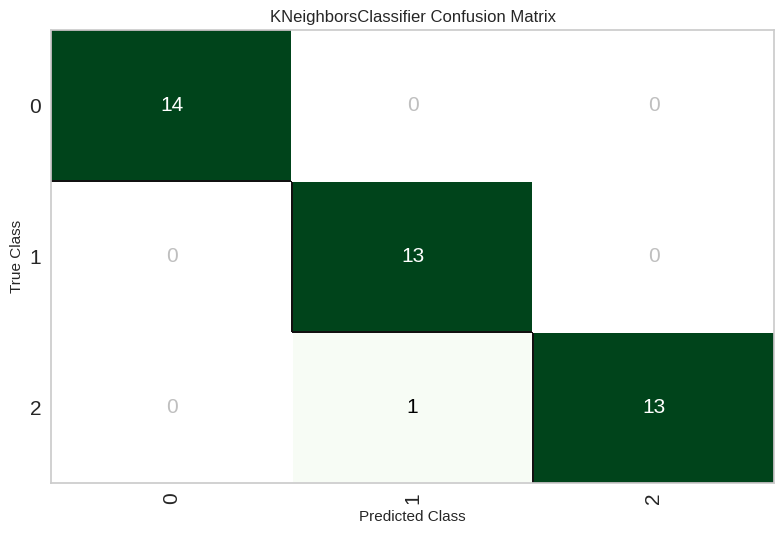

In [53]:
# gerar a matriz de confusão

from pycaret.classification import plot_model

plot_model(knn_tuning, plot = 'confusion_matrix')



eixo = y dados verdadeiros

eixo = x dados previstos

aparentemente a previsão foi boa

In [56]:
#Target mapping	Iris-setosa: 0, Iris-versicolor: 1, Iris-virginica: 2

# experimento['Target mapping']

# Em vez de experimento['Target mapping'], use:
mapeamento = experimento.get_config('target_param')
print(mapeamento)

species


In [57]:
# Isso mostrará tudo que você pode acessar (X_train, y_train, seed, etc.)
print(experimento.variables)

In [58]:
experimento.pull()

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,0.0,1.0000,1.0000,1.0000,1.0000,1.0000
1,1.0000,0.0,1.0000,1.0000,1.0000,1.0000,1.0000
2,1.0000,0.0,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,0.0,1.0000,1.0000,1.0000,1.0000,1.0000
4,0.8889,0.0,0.8889,0.9167,0.8857,0.8333,0.8492
5,0.8889,0.0,0.8889,0.9167,0.8857,0.8333,0.8492
6,1.0000,0.0,1.0000,1.0000,1.0000,1.0000,1.0000
7,1.0000,0.0,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,0.0,1.0000,1.0000,1.0000,1.0000,1.0000


In [59]:
y_transformado = experimento.get_config('y')
print(y_transformado.unique())

['Iris-virginica', 'Iris-versicolor', 'Iris-setosa']
Categories (3, object): ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


In [63]:
# Puxa o último resultado gerado (a tabela de setup)
tabela_setup = experimento.pull()

# Exibe a tabela
display(tabela_setup)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,0.0,1.0000,1.0000,1.0000,1.0000,1.0000
1,1.0000,0.0,1.0000,1.0000,1.0000,1.0000,1.0000
2,1.0000,0.0,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,0.0,1.0000,1.0000,1.0000,1.0000,1.0000
4,0.8889,0.0,0.8889,0.9167,0.8857,0.8333,0.8492
5,0.8889,0.0,0.8889,0.9167,0.8857,0.8333,0.8492
6,1.0000,0.0,1.0000,1.0000,1.0000,1.0000,1.0000
7,1.0000,0.0,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,0.0,1.0000,1.0000,1.0000,1.0000,1.0000


In [61]:
# Se o último comando foi compare_models(), ele trará o ranking dos modelos
ranking_modelos = experimento.pull()
display(ranking_modelos)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,0.0,1.0000,1.0000,1.0000,1.0000,1.0000
1,1.0000,0.0,1.0000,1.0000,1.0000,1.0000,1.0000
2,1.0000,0.0,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,0.0,1.0000,1.0000,1.0000,1.0000,1.0000
4,0.8889,0.0,0.8889,0.9167,0.8857,0.8333,0.8492
5,0.8889,0.0,0.8889,0.9167,0.8857,0.8333,0.8492
6,1.0000,0.0,1.0000,1.0000,1.0000,1.0000,1.0000
7,1.0000,0.0,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,0.0,1.0000,1.0000,1.0000,1.0000,1.0000


# voltando a aula

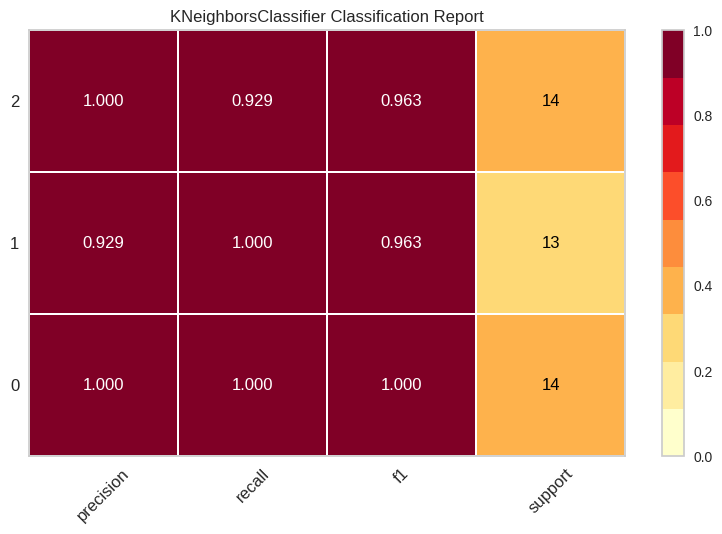

In [64]:
plot_model(knn_tuning, plot = 'class_report')

Temos a https://www.youtube.com/watch?app=desktop&v=fC_C695yVOk

precision

recall 

f1

support

Precisão = Qualidade (não dar alarme falso).

Recall = Quantidade (não deixar passar ninguém).

F1 = Equilíbrio entre Qualidade e Quantidade.

Support = Total de exemplos reais de cada classe.

1. Precision (Qualidade/Precisão)
A pergunta: "Segurança, de todas as malas que você parou dizendo que eram perigosas, quantas realmente tinham itens proibidos?"

O erro (Falso Positivo): Parar uma pessoa inocente e abrir a mala dela à toa.

Foco: Se a sua Precision é de 95%, significa que você quase nunca dá um "alarme falso".

2. Recall (Quantidade/Revocação)
A pergunta: "Segurança, de todas as malas perigosas que passaram por você hoje, quantas você conseguiu detectar?"

O erro (Falso Negativo): Deixar uma mala com itens proibidos passar direto para o avião.

Foco: Se o seu Recall é de 100%, você não deixou passar ninguém, mesmo que para isso tenha parado muita gente inocente por engano.

3. F1-Score (O Equilíbrio)
É a média que tenta ser justa. Um segurança que deixa todo mundo passar tem Recall 0. Um segurança que para todo mundo (até quem não deve) tem Precision baixa.

O F1-Score só será alto se o segurança for bom nas duas coisas: não incomodar inocentes (Precision) e não deixar bandidos passarem (Recall).

4. Support (A Realidade)
É apenas o número bruto.

"Quantas malas perigosas realmente existiam no aeroporto hoje?"

Se o Support for 5, e o seu Recall for 20%, significa que passaram 5 malas ruins e você só pegou 1.

# gráfico de divisões

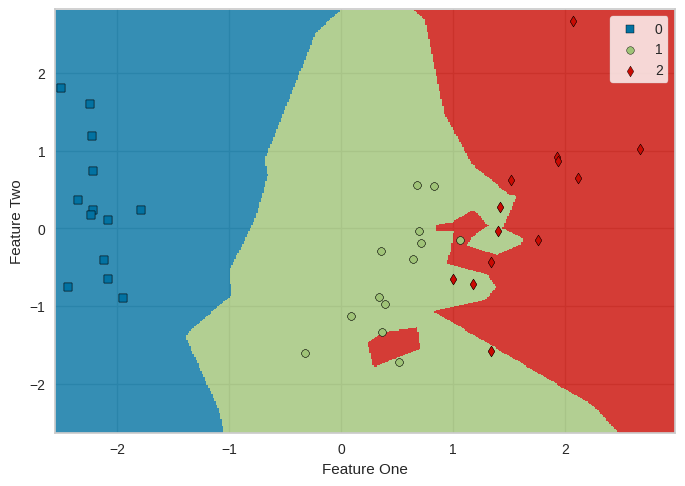

In [66]:
plot_model(knn_tuning, plot = 'boundary') # verifica onde cada categoria acertou, nota que no 2 houve previsto 1

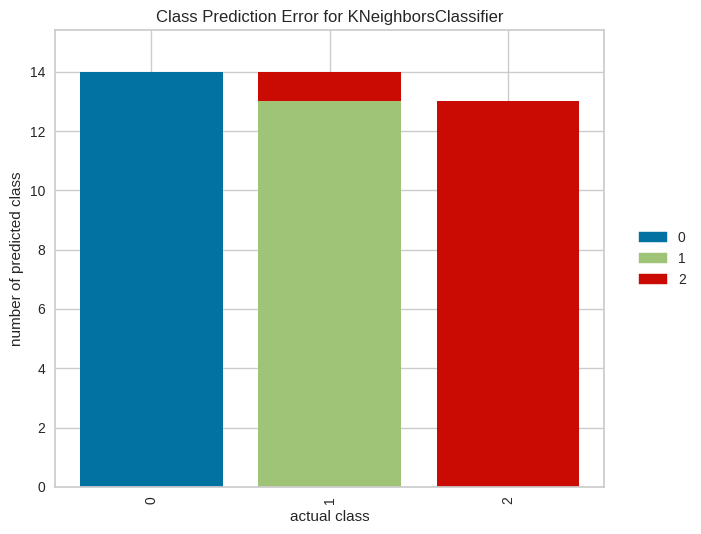

In [68]:
# erro indicado por classe
plot_model(knn_tuning, plot = 'error')

In [70]:
# alguns registros da classe 1 para a classe 2, mesma cor não há erro

### Target mapping	Iris-setosa: 0, Iris-versicolor: 1, Iris-virginica: 2

In [71]:
# função

# evaluate model


from pycaret.classification import evaluate_model

evaluate_model(knn_tuning)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

# resumo com vários gráficos, ver em clicks

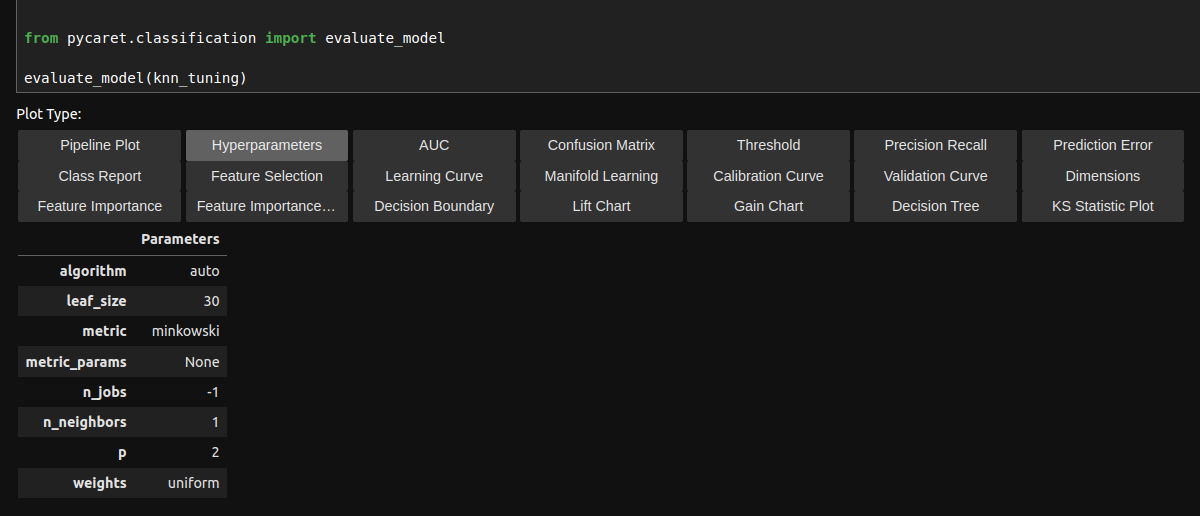

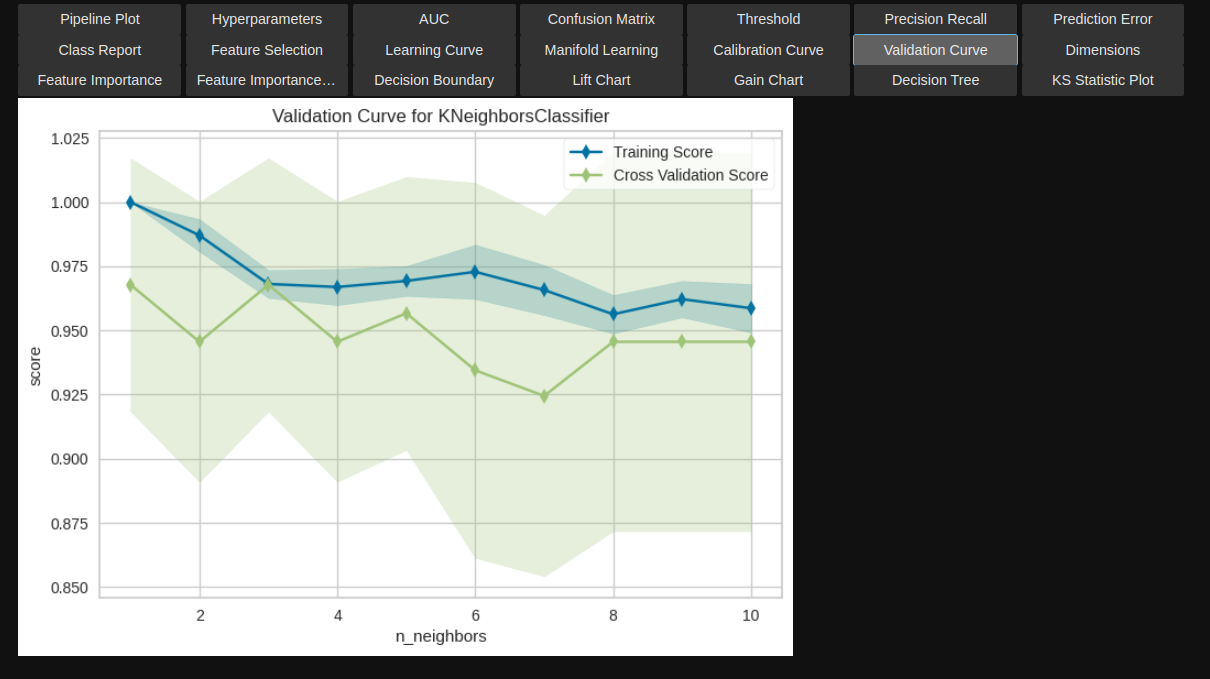

AUC, curva ROC

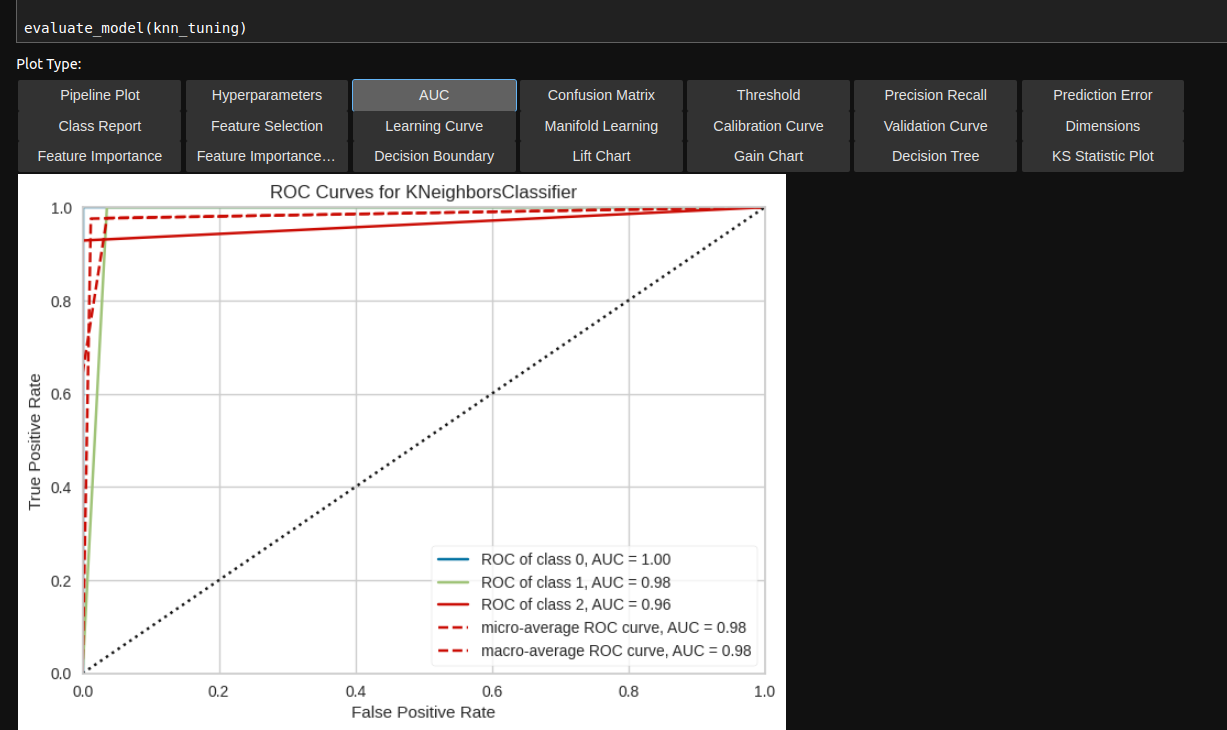

sem aplicar árvore de decisão  => Decision Tree

Feature Selection => não aplica seleção de caracteristicas

Feature Importance não aplicado => não aplicado

Feature Importance => não aplicado

learning curve aplicado

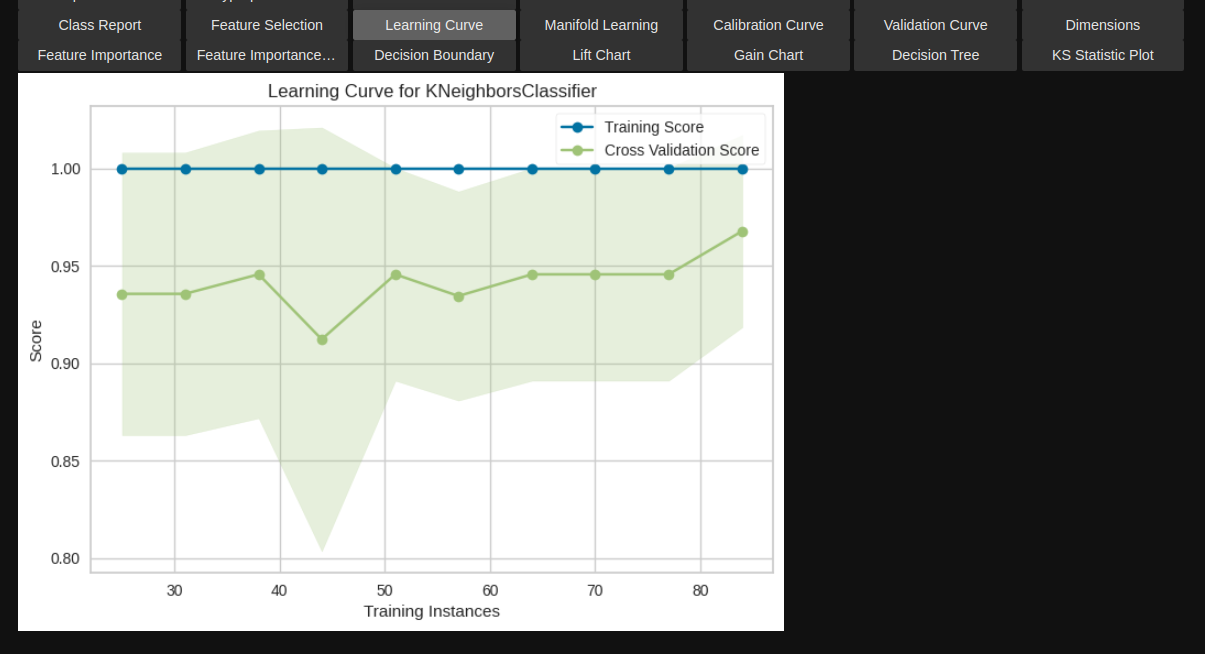


# qda -> Quadratic Discriminant Analysis

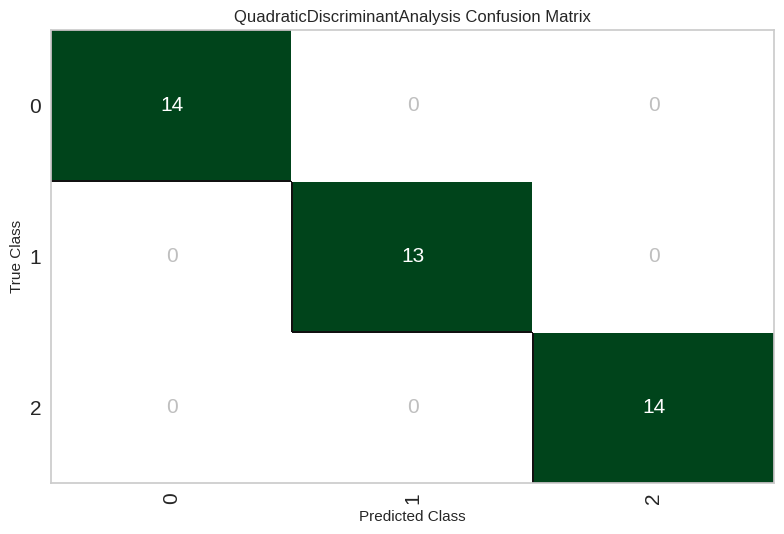

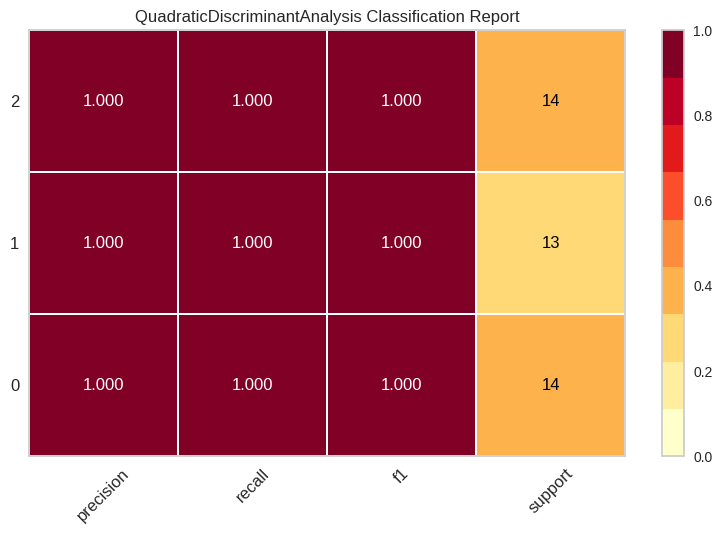

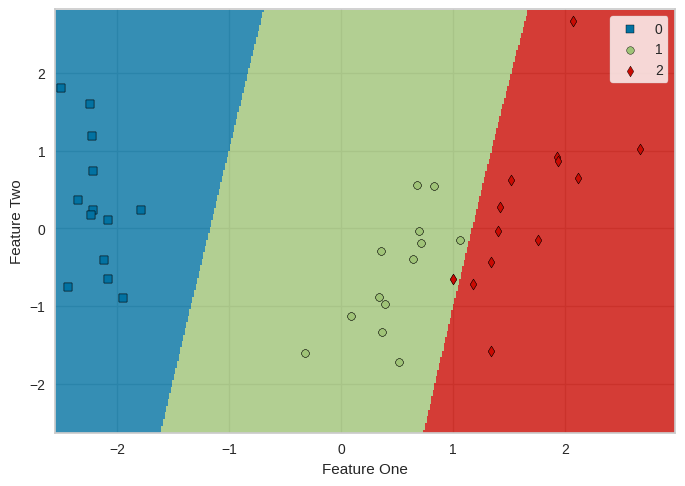

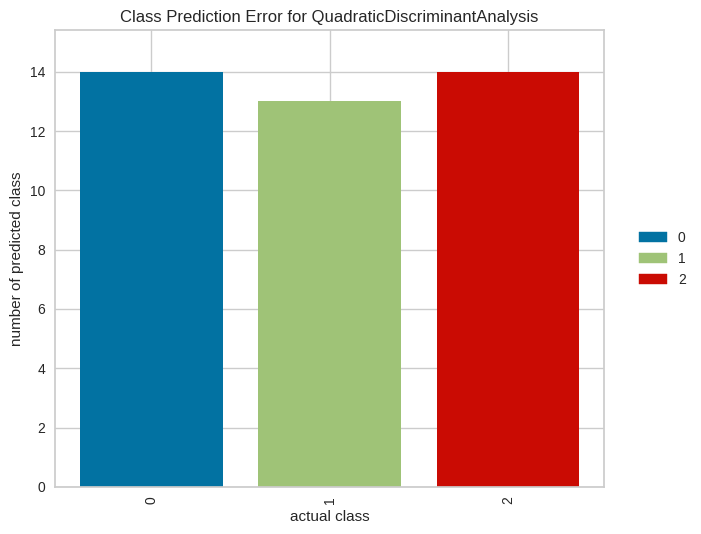

In [73]:
plot_model(qda, plot = 'confusion_matrix')

plot_model(qda, plot = 'class_report')

plot_model(qda, plot = 'boundary') # verifica onde cada categoria acertou, nota que no 2 houve previsto 1

plot_model(qda, plot = 'error')


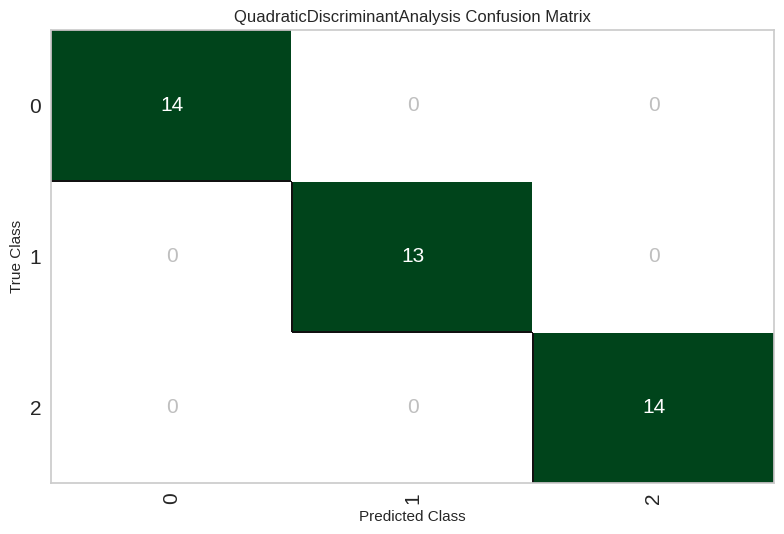

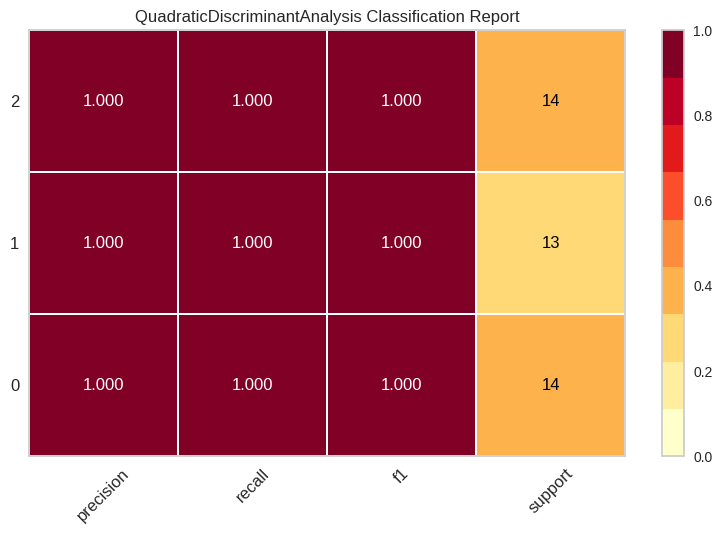

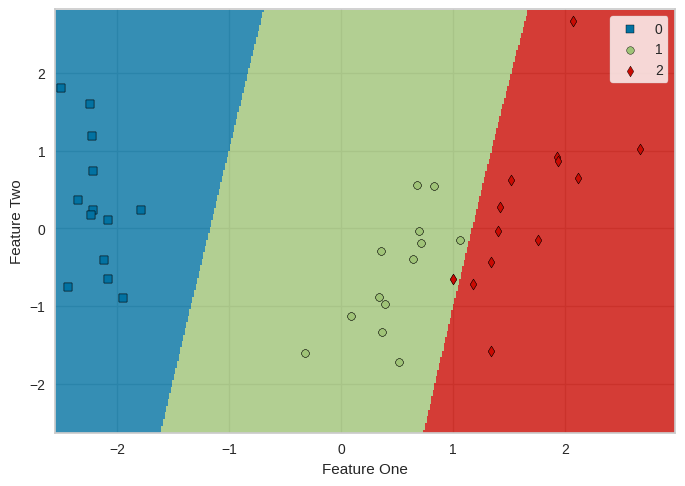

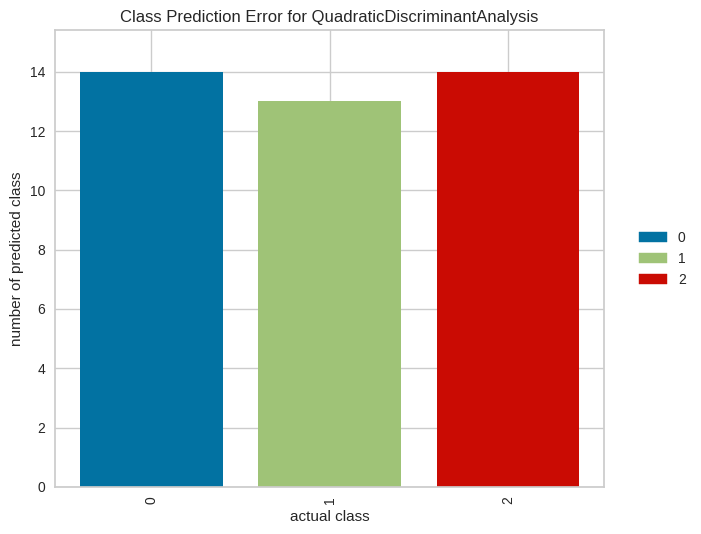

In [93]:
# correto
plot_model(qda, plot = 'confusion_matrix')

plot_model(qda_tuning, plot = 'class_report')

plot_model(qda_tuning, plot = 'boundary') # verifica onde cada categoria acertou, nota que no 2 houve previsto 1

plot_model(qda_tuning, plot = 'error')


## 32.3) Previsões com o MODELO

In [78]:
from pycaret.classification import predict_model
predict_model(knn_tuning);
# antes a acurácia era pela validação cruzada por 10 vezes, agora é um modelo único, por isso a diferença

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,K Neighbors Classifier,0.9756,0.9821,0.9756,0.9774,0.9756,0.9634,0.9643


### Precision

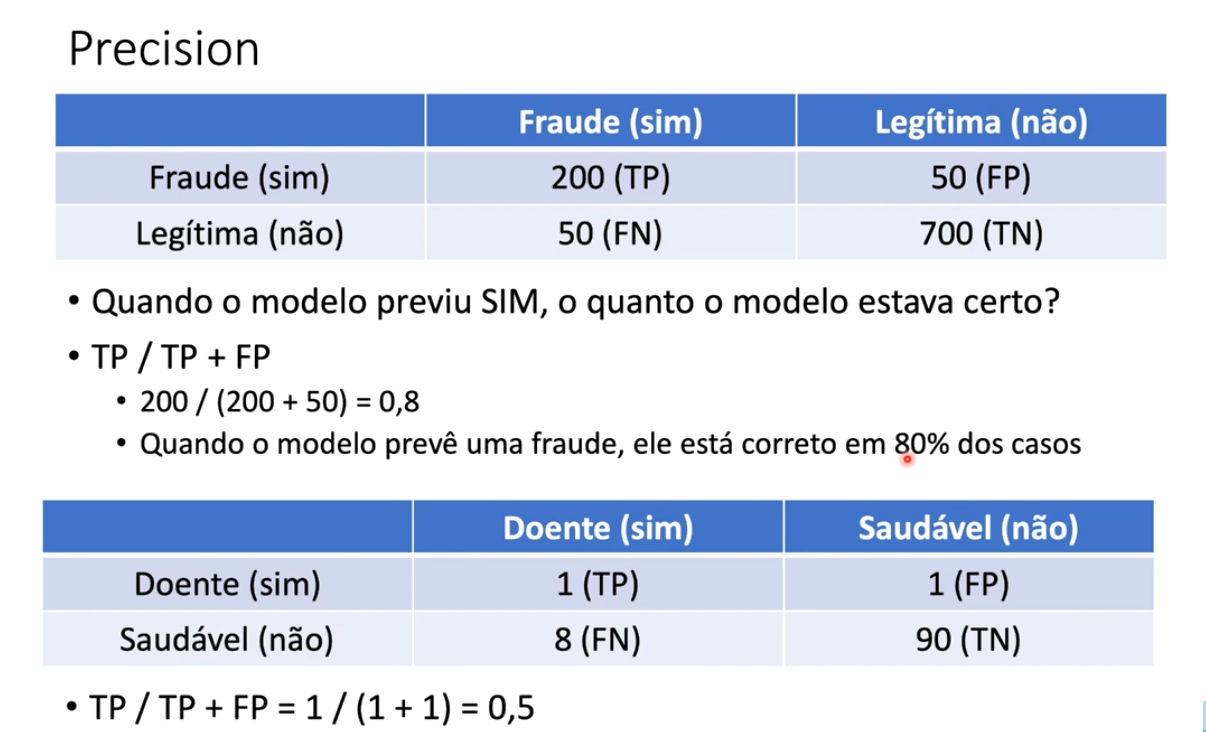

real fraude, recall
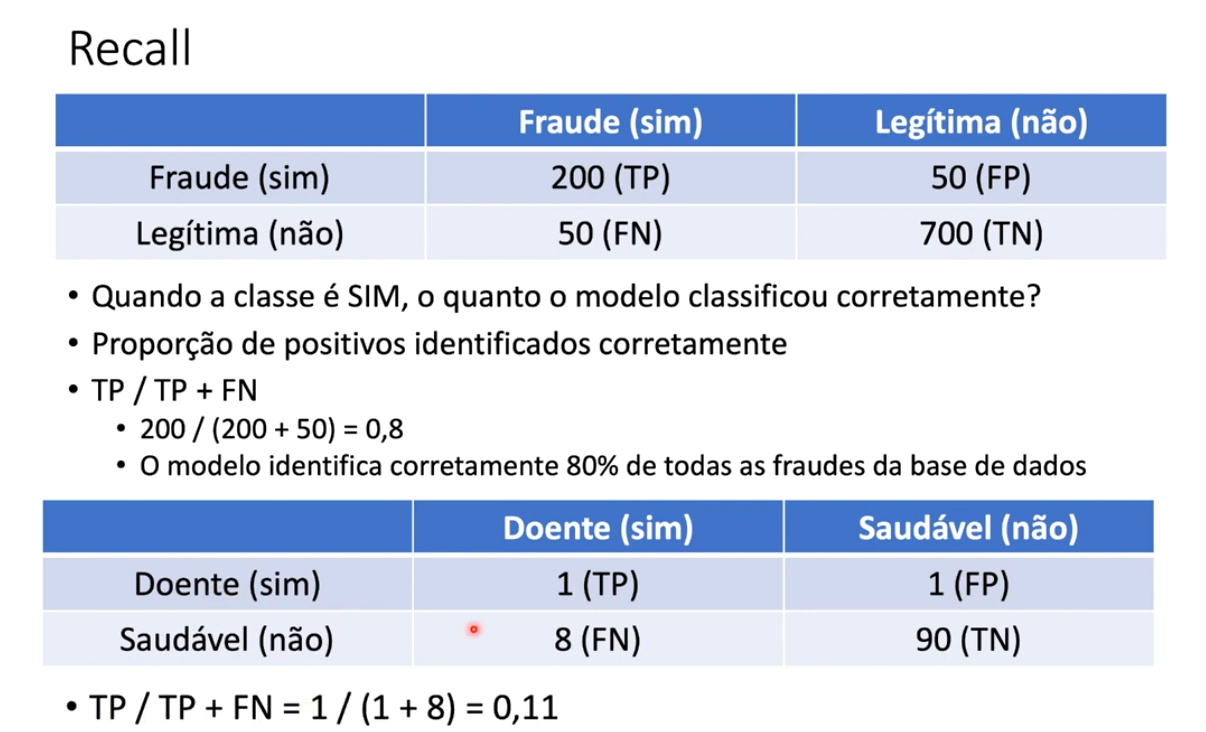


In [79]:
from pycaret.classification import finalize_model

knn_final = finalize_model(knn_tuning)
print(knn_final)

Pipeline(memory=Memory(location=None),
         steps=[('label_encoding',
                 TransformerWrapperWithInverse(exclude=None, include=None,
                                               transformer=LabelEncoder())),
                ('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['sepal_length', 'sepal_width',
                                             'petal_length', 'petal_width'],
                                    transformer=SimpleImputer(add_indicator=False,
                                                              copy=True,
                                                              fill_value=None,
                                                              keep_empt...
                 TransformerWrapper(exclude=None, include=[],
                                    transformer=SimpleImputer(add_indicator=False,
                                                              copy=True,
     

### importar os dados para o finalize_model; Isso é para gerar o modelo final. usando o melhor parâmetro (knn_tuning)

In [81]:
# salvando o modelo
from pycaret.classification import save_model

save_model(knn_final, 'knn')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['sepal_length', 'sepal_width',
                                              'petal_length', 'petal_width'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empt...
                  TransformerWrapper(exclude=None, include=[],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               c

In [83]:
# com isso salva o arquivo knn.pkl => modelo que foi salvo no sistema, pronto para a execução

In [84]:
# Isso vai listar n_neighbors, metric, leaf_size, etc.
print(knn_final.get_params())

{'memory': Memory(location=None), 'steps': [('label_encoding', TransformerWrapperWithInverse(exclude=None, include=None,
                              transformer=LabelEncoder())), ('numerical_imputer', TransformerWrapper(exclude=None,
                   include=['sepal_length', 'sepal_width', 'petal_length',
                            'petal_width'],
                   transformer=SimpleImputer(add_indicator=False, copy=True,
                                             fill_value=None,
                                             keep_empty_features=False,
                                             missing_values=nan,
                                             strategy='mean'))), ('categorical_imputer', TransformerWrapper(exclude=None, include=[],
                   transformer=SimpleImputer(add_indicator=False, copy=True,
                                             fill_value=None,
                                             keep_empty_features=False,
                        

In [85]:
# nova importação

from pycaret.classification import load_model
knn_carregado = load_model('knn') # salva por default nesta extensão

Transformation Pipeline and Model Successfully Loaded


In [87]:

from pycaret.classification import load_model
#knn_carregado = load_model('knn.pkl') # leitura do arquivo real

In [88]:
# base de 15 registros separados => base_teste
display(base_teste)

,sepal_length,sepal_width,petal_length,petal_width,species
20,5.4,3.4,1.7,0.2,Iris-setosa
25,5.0,3.0,1.6,0.2,Iris-setosa
37,4.9,3.1,1.5,0.1,Iris-setosa
50,7.0,3.2,4.7,1.4,Iris-versicolor
68,6.2,2.2,4.5,1.5,Iris-versicolor
71,6.1,2.8,4.0,1.3,Iris-versicolor
72,6.3,2.5,4.9,1.5,Iris-versicolor
79,5.7,2.6,3.5,1.0,Iris-versicolor
96,5.7,2.9,4.2,1.3,Iris-versicolor
101,5.8,2.7,5.1,1.9,Iris-virginica


In [92]:
# base de 15 registros separados => base_teste
previsoes = predict_model(knn_carregado, data=base_teste)

previsoes



,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,K Neighbors Classifier,0.8667,0.8889,0.8667,0.8667,0.8667,0.7917,0.7917


,sepal_length,sepal_width,petal_length,petal_width,species,prediction_label,prediction_score
20,5.4,3.4,1.7,0.2,Iris-setosa,Iris-setosa,1.0
25,5.0,3.0,1.6,0.2,Iris-setosa,Iris-setosa,1.0
37,4.9,3.1,1.5,0.1,Iris-setosa,Iris-setosa,1.0
50,7.0,3.2,4.7,1.4,Iris-versicolor,Iris-versicolor,1.0
68,6.2,2.2,4.5,1.5,Iris-versicolor,Iris-versicolor,1.0
71,6.1,2.8,4.0,1.3,Iris-versicolor,Iris-versicolor,1.0
72,6.3,2.5,4.9,1.5,Iris-versicolor,Iris-virginica,1.0
79,5.7,2.6,3.5,1.0,Iris-versicolor,Iris-versicolor,1.0
96,5.7,2.9,4.2,1.3,Iris-versicolor,Iris-versicolor,1.0
101,5.8,2.7,5.1,1.9,Iris-virginica,Iris-virginica,1.0


### species já é a base de dados origina, o prediction_labelé a previsão

as colunas prediction_label	 e prediction_score são as únicas de previsão do algoritmo; as demais são originais

score é a confiabilidade. 

Já na linha 72	6.3	2.5	4.9	1.5	Iris-versicolor	Iris-virginica	1.0 houve uma previsão errada, por exemplo

133	6.3	2.8	5.1	1.5	Iris-virginica	Iris-versicolor	1.

qda_tuning

In [97]:



from pycaret.classification import predict_model
predict_model(qda_tuning);
# antes a acurácia era pela validação cruzada por 10 vezes, agora é um modelo único, por isso a diferença


from pycaret.classification import finalize_model

qda_final = finalize_model(qda_tuning)
print(qda_final)


# salvando o modelo
from pycaret.classification import save_model

save_model(qda_final, 'qda')

# Isso vai listar n_neighbors, metric, leaf_size, etc.
print(qda_final.get_params())

# nova importação

from pycaret.classification import load_model
qda_carregado = load_model('qda') # salva por default nesta extensão

# base de 15 registros separados => base_teste
previsoes_c_qda = predict_model(qda_carregado, data=base_teste)

previsoes_c_qda

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Quadratic Discriminant Analysis,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Pipeline(memory=Memory(location=None),
         steps=[('label_encoding',
                 TransformerWrapperWithInverse(exclude=None, include=None,
                                               transformer=LabelEncoder())),
                ('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['sepal_length', 'sepal_width',
                                             'petal_length', 'petal_width'],
                                    transformer=SimpleImputer(add_indicator=False,
                                                              copy=True,
                                                              fill_value=None,
                                                              keep_empt...
                                                              strategy='mean'))),
                ('categorical_imputer',
                 TransformerWrapper(exclude=None, include=[],
                                    tra

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Quadratic Discriminant Analysis,0.8000,0.9704,0.8000,0.8057,0.7986,0.6875,0.6923


,sepal_length,sepal_width,petal_length,petal_width,species,prediction_label,prediction_score
20,5.4,3.4,1.7,0.2,Iris-setosa,Iris-setosa,1.0000
25,5.0,3.0,1.6,0.2,Iris-setosa,Iris-setosa,1.0000
37,4.9,3.1,1.5,0.1,Iris-setosa,Iris-setosa,1.0000
50,7.0,3.2,4.7,1.4,Iris-versicolor,Iris-versicolor,1.0000
68,6.2,2.2,4.5,1.5,Iris-versicolor,Iris-virginica,0.8661
71,6.1,2.8,4.0,1.3,Iris-versicolor,Iris-versicolor,1.0000
72,6.3,2.5,4.9,1.5,Iris-versicolor,Iris-virginica,0.5226
79,5.7,2.6,3.5,1.0,Iris-versicolor,Iris-versicolor,1.0000
96,5.7,2.9,4.2,1.3,Iris-versicolor,Iris-versicolor,0.9998
101,5.8,2.7,5.1,1.9,Iris-virginica,Iris-virginica,1.0000
